# 14장 (2단계) - supervisor 라우팅 멀티에이전트\n\n`supervisor`가 `with_structured_output(Task)`로 다음 agent(`content_strategist`/`communicator`)를 정하고, `add_conditional_edges`로 분기한다. `task_history`로 작업 이력을 관리한다.\n\n> `.env`에 `OPENAI_API_KEY`(OpenRouter)가 필요합니다. 노트북은 **chap14 폴더에서** 실행하세요.

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers.string import StrOutputParser
from typing_extensions import TypedDict
from typing import List, Union
from utils import save_state, get_outline, save_outline
from models import Task
from datetime import datetime
from dotenv import load_dotenv
import os

load_dotenv()

# 노트북은 __file__ 이 없으므로 현재 작업 폴더(chap14)를 기준 경로로 사용
current_path = os.getcwd()

# 모델 초기화 (OpenAI API 대신 OpenRouter 사용)
llm = ChatOpenAI(
    model="openai/gpt-4o",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv('OPENAI_API_KEY'),
)

/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 상태 정의
class State(TypedDict):
    messages: List[Union[AnyMessage, str]]
    task_history: List[Task]

In [3]:
# 어떤 agent에게 일을 시킬지 판단하는 supervisor 에이전트
def supervisor(state: State):
    print("\n\n============ SUPERVISOR ============")

    supervisor_system_prompt = PromptTemplate.from_template(
        """
        너는 AI 팀의 supervisor로서 AI 팀의 작업을 관리하고 지도한다.
        사용자가 원하는 책을 써야 한다는 최종 목표를 염두에 두고,
        사용자의 요구를 달성하기 위해 현재 해야할 일이 무엇인지 결정한다.

        supervisor가 활용할 수 있는 agent는 다음과 같다.
        - content_strategist: 사용자의 요구사항이 명확해졌을 때 사용한다. AI 팀의 콘텐츠 전략을 결정하고, 전체 책의 목차(outline)를 작성한다.
        - communicator: AI 팀에서 해야 할 일을 스스로 판단할 수 없을 때 사용한다. 사용자에게 진행상황을 보고하고, 다음 지시를 물어본다.

        아래 내용을 고려하여, 현재 해야할 일이 무엇인지, 사용할 수 있는 agent를 판단하라.

        --------------------------------
        previous_outline: {outline}
        --------------------------------
        messages:
        {messages}
        """
    )

    # 체인 연결 (구조화된 출력으로 Task를 생성 → 불필요한 문장이 섞이는 문제 방지)
    supervisor_chain = supervisor_system_prompt | llm.with_structured_output(Task)

    messages = state.get("messages", [])

    inputs = {
        "messages": messages,
        "outline": get_outline(current_path),
    }

    task = supervisor_chain.invoke(inputs)

    task_history = state.get("task_history", [])
    task_history.append(task)

    supervisor_message = AIMessage(f"[Supervisor] {task}")
    messages.append(supervisor_message)
    print(supervisor_message.content)

    return {
        "messages": messages,
        "task_history": task_history,
    }


# supervisor's route
def supervisor_router(state: State):
    task = state['task_history'][-1]
    return task.agent

In [4]:
# 목차를 작성하는 노드(agent)
def content_strategist(state: State):
    print("\n\n============ CONTENT STRATEGIST ============")

    content_strategist_system_prompt = PromptTemplate.from_template(
        """
        너는 책을 쓰는 AI팀의 콘텐츠 전략가(Content Strategist)로서,
        이전 대화 내용을 바탕으로 사용자의 요구사항을 분석하고, AI팀이 쓸 책의 세부 목차를 결정한다.

        지난 목차가 있다면 그 버전을 사용자의 요구에 맞게 수정하고, 없다면 새로운 목차를 제안한다.

        --------------------------------
        - 지난 목차: {outline}
        --------------------------------
        - 이전 대화 내용: {messages}
        """
    )

    content_strategist_chain = content_strategist_system_prompt | llm | StrOutputParser()

    messages = state["messages"]
    outline = get_outline(current_path)

    inputs = {
        "messages": messages,
        "outline": outline,
    }

    gathered = ''
    for chunk in content_strategist_chain.stream(inputs):
        gathered += chunk
        print(chunk, end='')

    print()

    save_outline(current_path, gathered)

    content_strategist_message = "[Content Strategist] 목차 작성 완료"
    print(content_strategist_message)
    messages.append(AIMessage(content_strategist_message))

    task_history = state.get("task_history", [])
    if task_history[-1].agent != "content_strategist":
        raise ValueError(f"Content Strategist가 아닌 agent가 목차 작성을 시도하고 있습니다.\n {task_history[-1]}")

    task_history[-1].done = True
    task_history[-1].done_at = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # 다음 작업이 communicator로 사용자와 대화하는 것이므로 새 작업 추가
    new_task = Task(
        agent="communicator",
        done=False,
        description="AI팀의 진행상황을 사용자에게 보고하고, 사용자의 의견을 파악하기 위한 대화를 나눈다",
        done_at="",
    )
    task_history.append(new_task)

    print(new_task)

    return {
        "messages": messages,
        "task_history": task_history,
    }

In [5]:
# 사용자와 대화할 노드(agent): communicator
def communicator(state: State):
    print("\n\n============ COMMUNICATOR ============")

    communicator_system_prompt = PromptTemplate.from_template(
        """
        너는 책을 쓰는 AI팀의 커뮤니케이터로서,
        AI팀의 진행상황을 사용자에게 보고하고, 사용자의 의견을 파악하기 위한 대화를 나눈다.

        사용자도 outline(목차)을 이미 보고 있으므로, 다시 출력할 필요는 없다.
        outline: {outline}
        --------------------------------
        messages: {messages}
        """
    )

    system_chain = communicator_system_prompt | llm

    messages = state["messages"]

    inputs = {
        "messages": messages,
        "outline": get_outline(current_path),
    }

    gathered = None

    print('\nAI\t: ', end='')
    for chunk in system_chain.stream(inputs):
        print(chunk.content, end='')

        if gathered is None:
            gathered = chunk
        else:
            gathered += chunk

    messages.append(gathered)

    task_history = state.get("task_history", [])
    if task_history[-1].agent != "communicator":
        raise ValueError(f"Communicator가 아닌 agent가 대화를 시도하고 있습니다.\n {task_history[-1]}")

    task_history[-1].done = True
    task_history[-1].done_at = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    return {
        "messages": messages,
        "task_history": task_history,
    }

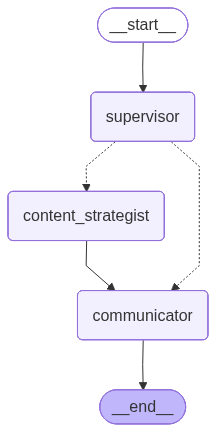

In [6]:
from IPython.display import Image, display

# 상태 그래프 정의
graph_builder = StateGraph(State)

# Nodes
graph_builder.add_node("supervisor", supervisor)
graph_builder.add_node("communicator", communicator)
graph_builder.add_node("content_strategist", content_strategist)

# Edges
graph_builder.add_edge(START, "supervisor")
graph_builder.add_conditional_edges(
    "supervisor",
    supervisor_router,
    {
        "content_strategist": "content_strategist",
        "communicator": "communicator",
    }
)
graph_builder.add_edge("content_strategist", "communicator")
graph_builder.add_edge("communicator", END)

graph = graph_builder.compile()

# 그래프 도식화 (노트북에서는 인라인으로 표시)
display(Image(graph.get_graph().draw_mermaid_png()))

## 실행\n아래 셀을 실행하면 입력창이 나타납니다. `HYBE와 JYP 경영 전략을 비교하는 책을 써줘` 처럼 입력하고, `q`로 종료하세요.

In [8]:
# 상태 초기화
state = State(
    messages=[
        SystemMessage(
            f"""
            너희 AI들은 사용자의 요구에 맞는 책을 쓰는 작가팀이다.
            사용자가 사용하는 언어로 대화하라.

            현재시각은 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}이다.
            """
        )
    ],
    task_history=[],
)

# 아래 셀을 실행하면 입력창이 나타난다. 책 주제를 입력하고, exit / quit / q 로 종료한다.
while True:
    user_input = input("\nUser\t: ").strip()

    if user_input.lower() in ['exit', 'quit', 'q']:
        print("Goodbye!")
        break

    state["messages"].append(HumanMessage(user_input))
    state = graph.invoke(state)

    print('\n----------------------------------- MESSAGE COUNT\t', len(state["messages"]))

    save_state(current_path, state)



============ SUPERVISOR ============


/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Task(agent='communicator'...t='2026-07-06 13:54:07'), input_type=Task])
  return self.__pydantic_serializer__.to_python(


[Supervisor] agent='communicator' done=False description='사용자에게 세부 목차에 대해 피드백을 요청하고, 추가하고 싶은 내용이나 특정 주제에 대한 정보를 물어본다.' done_at='2026-07-06 13:54:07'


============ COMMUNICATOR ============

AI	: 안녕하세요! 저희 AI팀의 책 작업에 대해 이야기 나눠보게 되어 반갑습니다. 제안드린 목차를 바탕으로 추가하고 싶은 내용이나 특정 주제가 있는지 궁금합니다. 혹시 특정한 방향이나 주제에 대해 더 이야기하고 싶으신 부분이 있다면 말씀해 주세요. 그에 따라 목차를 수정하거나 보완할 수 있습니다!
----------------------------------- MESSAGE COUNT	 4


KeyboardInterrupt: Interrupted by user